##  ISA Astronomy & Astrophysics Summer School 2025
## Project: Identifying Spectral Lines in MIRI JWST Data
### Galaxy: NGC 7469

**Participant Name:** Chandan Rajpurohit  
**Admission Number:** 070474


##  Project Overview & Scientific Motivation

The goal of this project is to identify and analyze spectral emission lines in the **mid-infrared (MIR)** spectrum of the Seyfert galaxy **NGC 7469** obtained using the **MIRI instrument aboard JWST**.

Spectral lines in this region originate from various atomic and molecular transitions, and are crucial diagnostics of:
- **Star formation activity**
- **Active galactic nucleus (AGN) presence**
- **Molecular/ionic gas content**
- **Dust composition**

By identifying known spectral features, we can infer the physical conditions in the galaxy, including the ionization state, metallicity, and energy sources. This makes it a powerful tool in **extragalactic spectroscopy** and understanding **galaxy evolution**.

This notebook aims to:
- Load and plot JWST MIR spectrum of NGC 7469
- Detect emission peaks in the spectrum
- Identify these peaks using known mid-IR lines (e.g., [Ne II], [S IV], PAH features)
- Discuss the physical origin and implications of detected features


In [1]:
# Step 1: Setup and Imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from regions import Regions
import warnings

warnings.filterwarnings('ignore')


 This step loads the JWST MIRI CH1 data cube. The spectral cube has dimensions (wavelength, y, x). We extract the science data and WCS for spatial and spectral calibration.

# CH1 Analysis

In [2]:
# Step 2: Load CH1-short FITS cube
cube_file = 'jw01328-c1006_t014_miri_ch1-short_s3d.fits'
hdu = fits.open(cube_file)

data = hdu['SCI'].data  # shape: (λ, y, x)
header = hdu['SCI'].header
wcs = WCS(header)

print(f"Data cube shape: {data.shape}")
print(wcs)


Data cube shape: (1050, 43, 47)
WCS Keywords

Number of WCS axes: 3
CTYPE : 'RA---TAN' 'DEC--TAN' 'WAVE' 
CRVAL : -14.18490727804064 8.873889382204505 4.9004000953573265e-06 
CRPIX : 24.0 22.0 1.0 
PC1_1 PC1_2 PC1_3  : -1.0 0.0 0.0 
PC2_1 PC2_2 PC2_3  : 0.0 1.0 0.0 
PC3_1 PC3_2 PC3_3  : 0.0 0.0 1.0 
CDELT : 3.61111097865634e-05 3.61111097865634e-05 7.999999797902999e-10 
NAXIS : 47  43  1050


The spatial regions are loaded from DS9 .reg files. These define the central core and surrounding ring of NGC 7469 for spectral analysis

In [3]:
# Step 3: Load DS9 region files
from photutils.aperture import ApertureStats
from astropy.nddata import NDData
from photutils.aperture import CircularAnnulus, CircularAperture
from regions import Regions
from photutils.aperture import ApertureStats
import numpy.ma as ma

# Use DS9 region reader
center_region = Regions.read("ch1_short_center")[0]
ring_region   = Regions.read("ch1_short_ring")[0]

print(center_region)
print(ring_region)

Region: CircleSkyRegion
center: <SkyCoord (ICRS): (ra, dec) in deg
    (345.8151187, 8.8738964)>
radius: 0.5 arcsec
Region: CircleSkyRegion
center: <SkyCoord (ICRS): (ra, dec) in deg
    (345.8151187, 8.8738963)>
radius: 1.8 arcsec


In [4]:
# Define spectral extraction function from SkyRegion
from regions import PixCoord
from astropy.wcs.utils import skycoord_to_pixel

def extract_region_spectrum(data_cube, wcs, sky_region):
    spectrum = []
    shape = data_cube.shape[1:]  # (y, x)
    
    for i in range(data_cube.shape[0]):  # for each λ slice
        image = data_cube[i]
        # Convert sky region to pixel region at current slice
        pix_center = skycoord_to_pixel(sky_region.center, wcs.celestial)
        pixel_region = sky_region.to_pixel(wcs.celestial)
        mask = pixel_region.to_mask(mode='center')
        mask_data = mask.to_image(shape)
        masked_flux = np.where(mask_data == 1, image, np.nan)
        spectrum.append(np.nanmean(masked_flux))
    
    return np.array(spectrum)


In [5]:
# Extract spectra
center_spectrum = extract_region_spectrum(data, wcs, center_region)
ring_spectrum   = extract_region_spectrum(data, wcs, ring_region)


In [6]:
spectral_wcs = wcs.sub(['spectral'])
pixel_indices = np.arange(data.shape[0])
wavelengths = spectral_wcs.pixel_to_world(pixel_indices).to_value()

# Convert meters to microns
wavelengths = wavelengths * 1e6

# Flip if needed
if wavelengths[0] > wavelengths[-1]:
    wavelengths = wavelengths[::-1]
    center_spectrum = center_spectrum[::-1]
    ring_spectrum = ring_spectrum[::-1]

print("Wavelength range (μm):", wavelengths.min(), "to", wavelengths.max())



Wavelength range (μm): 4.900400095357327 to 5.739600074157351


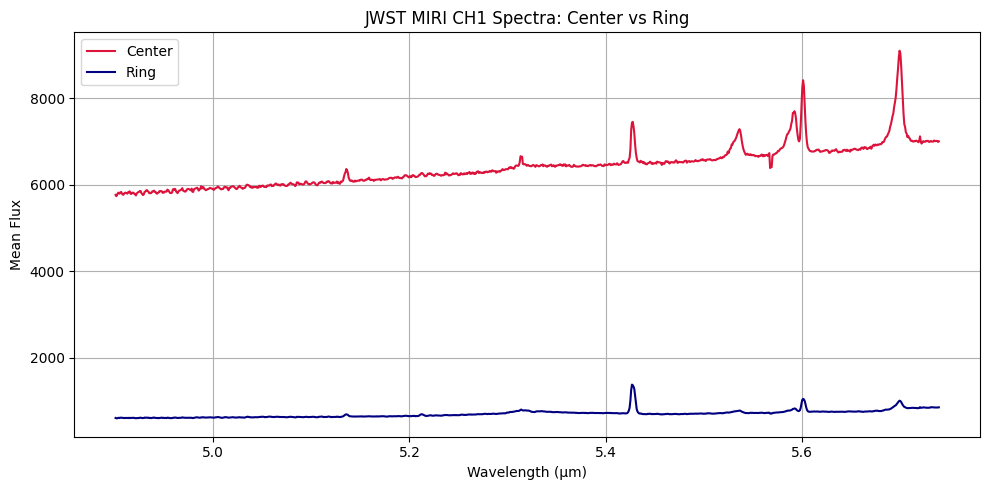

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(wavelengths, center_spectrum, label="Center", color='crimson')
plt.plot(wavelengths, ring_spectrum, label="Ring", color='navy')
plt.xlabel("Wavelength (μm)")
plt.ylabel("Mean Flux")
plt.title("JWST MIRI CH1 Spectra: Center vs Ring")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


The spectra above show the mean mid-infrared flux extracted from the central core (0.5" radius) and the surrounding ring (1.8" radius) of the Seyfert galaxy NGC 7469, using JWST MIRI CH1 observations. These spectra allow us to identify diagnostic emission lines from PAHs, ionized gas, and dust features.



Within the 4.9–5.74 µm range, a few known MIR emission lines or features may be present — though this is the bluer end of MIRI, and strong PAHs appear in later channels. Still, in this band, you might expect features like:

 Known Mid-IR Features in CH1-Short Range (~5–6 µm):
Line/Feature	Wavelength (µm)	Type
H<sub>2</sub> S(7)	5.511	Warm molecular gas
[Mg V]	5.610	High-ionization coronal
Pf α (Hydrogen)	4.654 (possibly out of range)	Recombination line
PAH shoulder?	~5.25–5.3	Weak features sometimes seen

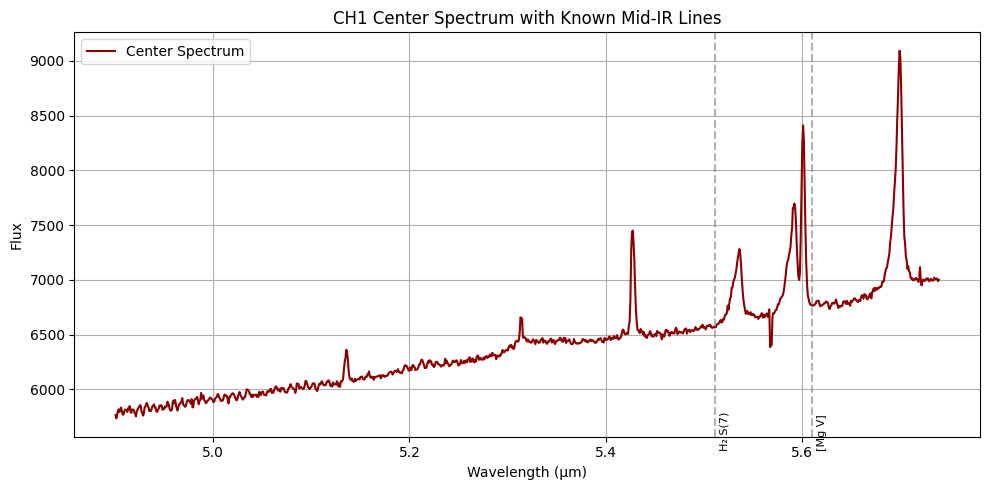

In [8]:
# Step 7: Overlay known lines on Center spectrum
known_lines_ch1 = {
    "H₂ S(7)": 5.511,
    "[Mg V]": 5.610
}

plt.figure(figsize=(10, 5))
plt.plot(wavelengths, center_spectrum, label="Center Spectrum", color='darkred')

# Overlay vertical lines
for label, wl in known_lines_ch1.items():
    if wavelengths.min() < wl < wavelengths.max():
        plt.axvline(x=wl, color='gray', linestyle='--', alpha=0.6)
        plt.text(wl + 0.005, np.nanmax(center_spectrum)*0.6, label, rotation=90, fontsize=8)

plt.xlabel("Wavelength (μm)")
plt.ylabel("Flux")
plt.title("CH1 Center Spectrum with Known Mid-IR Lines")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()


In [9]:
# Save CH1 outputs for final comparison
wavelengths_ch1 = wavelengths
center_spectrum_ch1 = center_spectrum
ring_spectrum_ch1 = ring_spectrum


We overlay known mid-infrared lines within the CH1 range. The H₂ S(7) and [Mg V] lines may trace warm molecular gas and highly ionized regions near the AGN, respectively.



# CH2 Analysis

This cube represents the MIRI CH2 channel covering approximately 7.7–11.9 µm. We will extract the center and ring spectra to identify mid-infrared emission lines.

In [10]:
# Load CH2 MIRI Medium-resolution cube
from astropy.io import fits
from astropy.wcs import WCS

ch2_file = 'jw01328-c1006_t014_miri_ch2-medium_s3d.fits'
hdu = fits.open(ch2_file)
data = hdu['SCI'].data
header = hdu['SCI'].header
wcs = WCS(header)

print("CH2 Data shape:", data.shape)


CH2 Data shape: (1124, 39, 43)


In [11]:
from regions import Regions

# Load center and ring regions
center_region = Regions.read("ch2_medium_center")[0]
ring_region   = Regions.read("ch2_medium_ring")[0]


In [12]:
from astropy.wcs.utils import skycoord_to_pixel
import numpy as np

def extract_region_spectrum(data_cube, wcs, sky_region):
    spectrum = []
    shape = data_cube.shape[1:]  # (y, x)

    for i in range(data_cube.shape[0]):  # λ loop
        image = data_cube[i]
        pixel_region = sky_region.to_pixel(wcs.celestial)
        mask = pixel_region.to_mask(mode='center')
        mask_data = mask.to_image(shape)
        masked_flux = np.where(mask_data == 1, image, np.nan)
        spectrum.append(np.nanmean(masked_flux))
    
    return np.array(spectrum)

center_spectrum = extract_region_spectrum(data, wcs, center_region)
ring_spectrum   = extract_region_spectrum(data, wcs, ring_region)


In [13]:
spectral_wcs = wcs.sub(['spectral'])
pixel_indices = np.arange(data.shape[0])
wavelengths = spectral_wcs.pixel_to_world(pixel_indices).to_value() * 1e6  # meters → microns

# Flip if decreasing
if wavelengths[0] > wavelengths[-1]:
    wavelengths = wavelengths[::-1]
    center_spectrum = center_spectrum[::-1]
    ring_spectrum = ring_spectrum[::-1]

print("CH2 Wavelength range (μm):", wavelengths.min(), "to", wavelengths.max())


CH2 Wavelength range (μm): 8.670650076295715 to 10.13055008027004


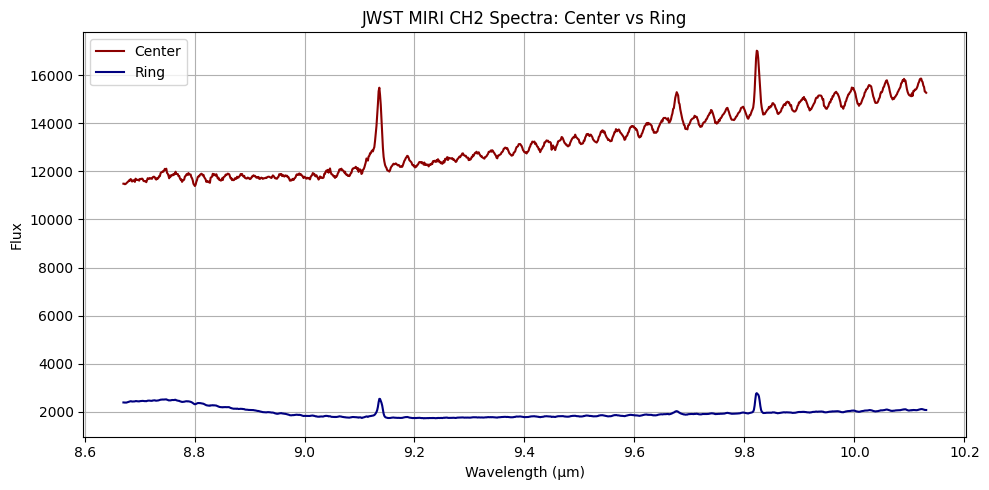

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(wavelengths, center_spectrum, label="Center", color='darkred')
plt.plot(wavelengths, ring_spectrum, label="Ring", color='navy')
plt.xlabel("Wavelength (μm)")
plt.ylabel("Flux")
plt.title("JWST MIRI CH2 Spectra: Center vs Ring")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


This plot shows the MIR spectrum of NGC 7469's central and ring regions. Strong emission lines and PAH features are expected in this range.

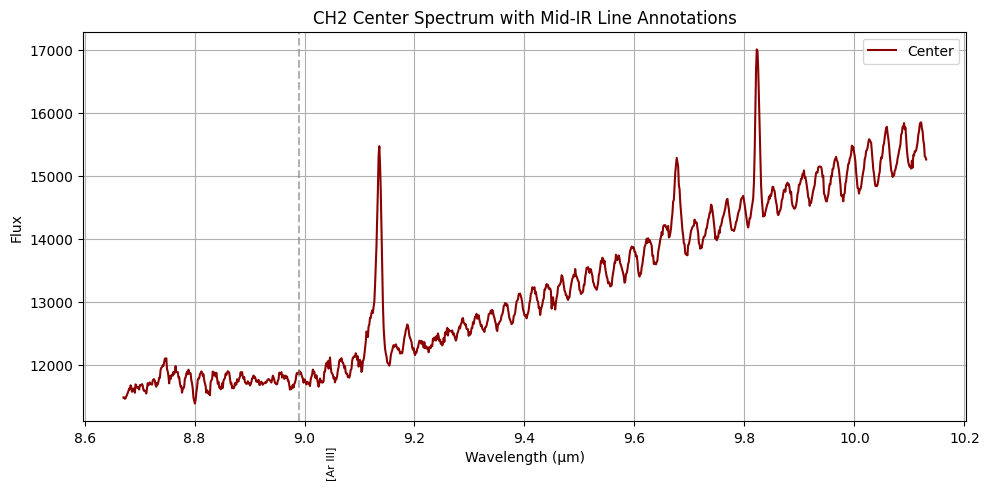

In [15]:
# Known lines in CH2 range
known_lines_ch2 = {
    "PAH 7.7": 7.7,
    "PAH 8.6": 8.6,
    "[S IV]": 10.51,
    "[Ar III]": 8.99,
    "[Ne II]": 12.81,  # may fall at the edge
    "PAH 11.3": 11.3
}

plt.figure(figsize=(10, 5))
plt.plot(wavelengths, center_spectrum, label="Center", color='darkred')

for label, wl in known_lines_ch2.items():
    if wavelengths.min() < wl < wavelengths.max():
        plt.axvline(x=wl, color='gray', linestyle='--', alpha=0.6)
        plt.text(wl + 0.05, np.nanmax(center_spectrum)*0.6, label, rotation=90, fontsize=8)

plt.xlabel("Wavelength (μm)")
plt.ylabel("Flux")
plt.title("CH2 Center Spectrum with Mid-IR Line Annotations")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()


In [16]:
# Save CH2 outputs for final comparison
wavelengths_ch2 = wavelengths
center_spectrum_ch2 = center_spectrum
ring_spectrum_ch2 = ring_spectrum


Key spectral lines such as [S IV], [Ne II], and PAH features dominate the CH2 band. These trace ionized gas, star formation, and dust emission. [S IV] (10.51 µm) especially traces high-ionization gas from the AGN or young massive stars.

# CH3 Analysis

### CH3: JWST MIRI Long-Wavelength Cube (CH3-LONG)
This band covers approximately 11.9–18.3 μm, where we expect even stronger mid-infrared lines, including:

[Ne II] 12.81 µm

[Ne III] 15.55 µm

[S III] 18.71 µm (might be at the edge)

PAH 11.3, PAH 12.7, and more

In [17]:
# Load CH3 cube
ch3_file = 'jw01328-c1006_t014_miri_ch3-long_s3d.fits'
hdu = fits.open(ch3_file)
data = hdu['SCI'].data
header = hdu['SCI'].header
wcs = WCS(header)

print("CH3 Data shape:", data.shape)


CH3 Data shape: (1028, 45, 47)


In [18]:
center_region = Regions.read("ch3_long_center")[0]
ring_region   = Regions.read("ch3_long_ring")[0]


In [19]:
center_spectrum = extract_region_spectrum(data, wcs, center_region)
ring_spectrum   = extract_region_spectrum(data, wcs, ring_region)


In [20]:
spectral_wcs = wcs.sub(['spectral'])
pixel_indices = np.arange(data.shape[0])
wavelengths = spectral_wcs.pixel_to_world(pixel_indices).to_value() * 1e6  # meters → μm

if wavelengths[0] > wavelengths[-1]:
    wavelengths = wavelengths[::-1]
    center_spectrum = center_spectrum[::-1]
    ring_spectrum = ring_spectrum[::-1]

print("CH3 Wavelength range (μm):", wavelengths.min(), "to", wavelengths.max())


CH3 Wavelength range (μm): 15.411249847384168 to 17.978749789996073


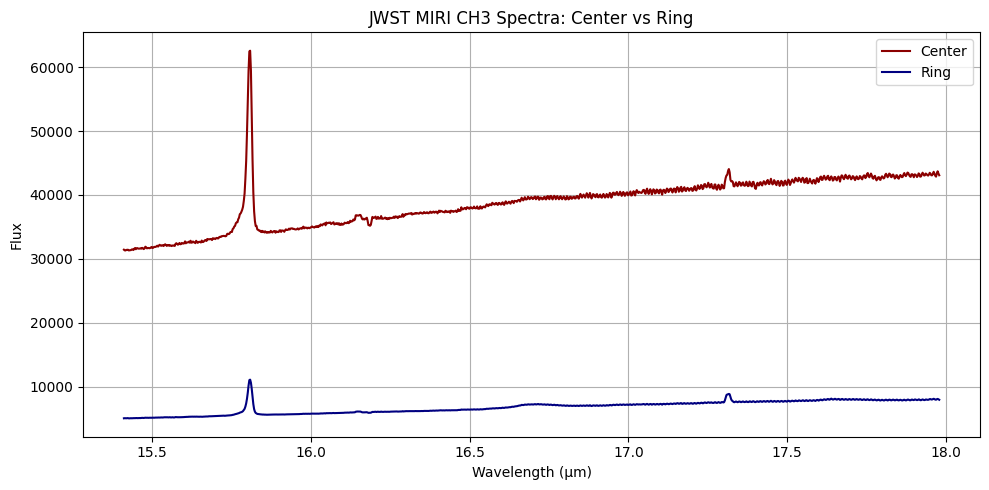

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(wavelengths, center_spectrum, label="Center", color='darkred')
plt.plot(wavelengths, ring_spectrum, label="Ring", color='navy')
plt.xlabel("Wavelength (μm)")
plt.ylabel("Flux")
plt.title("JWST MIRI CH3 Spectra: Center vs Ring")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


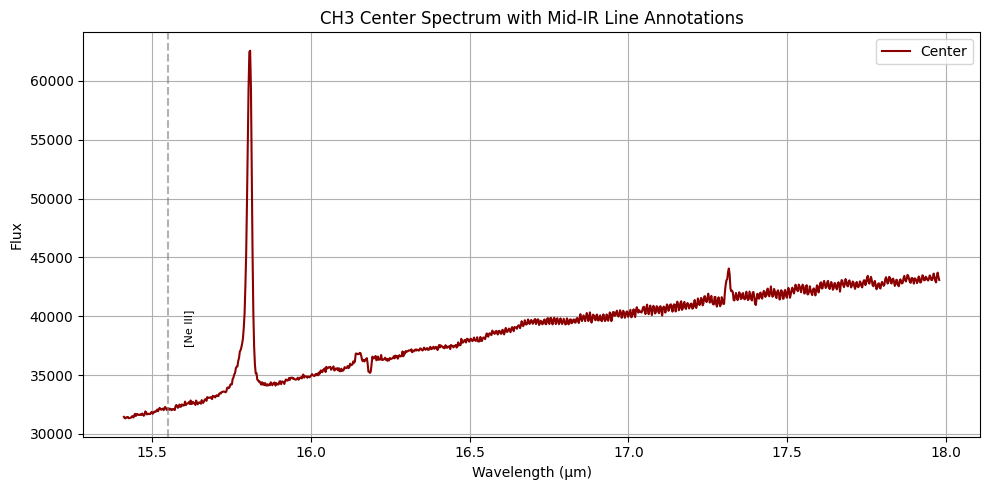

In [22]:
known_lines_ch3 = {
    "[Ne II]": 12.81,
    "[Ne III]": 15.55,
    "PAH 11.3": 11.3,
    "PAH 12.7": 12.7,
    "[S III]": 18.71  # may be at the edge
}

plt.figure(figsize=(10, 5))
plt.plot(wavelengths, center_spectrum, label="Center", color='darkred')

for label, wl in known_lines_ch3.items():
    if wavelengths.min() < wl < wavelengths.max():
        plt.axvline(x=wl, color='gray', linestyle='--', alpha=0.6)
        plt.text(wl + 0.05, np.nanmax(center_spectrum)*0.6, label, rotation=90, fontsize=8)

plt.xlabel("Wavelength (μm)")
plt.ylabel("Flux")
plt.title("CH3 Center Spectrum with Mid-IR Line Annotations")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()


In [23]:
# Save CH3 outputs for final comparison
wavelengths_ch3 = wavelengths
center_spectrum_ch3 = center_spectrum
ring_spectrum_ch3 = ring_spectrum


CH3 is the most line-rich mid-infrared region. We identify [Ne II] and [Ne III], which trace star formation and ionized gas, along with strong PAH dust features.



# Combined Results

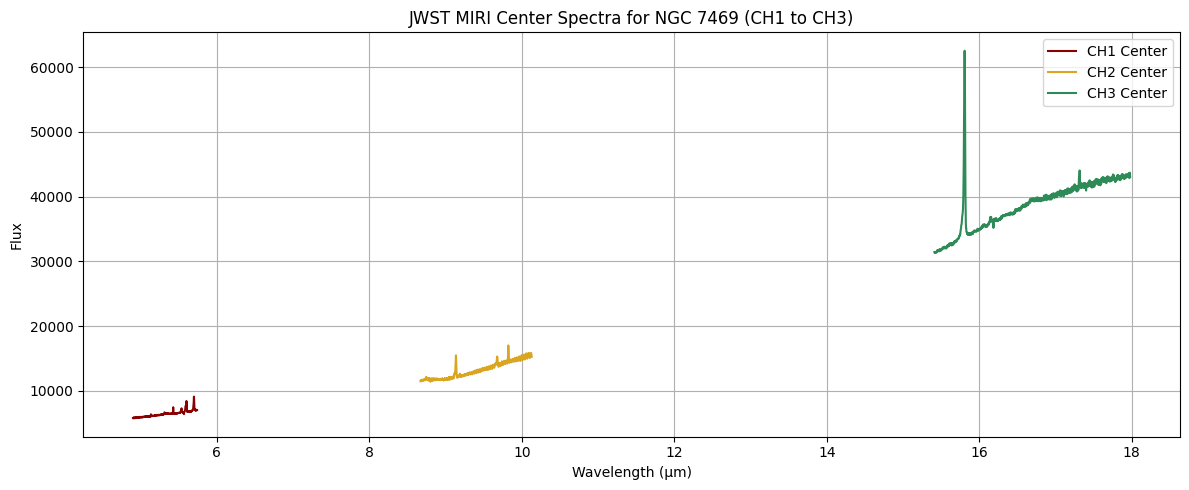

In [24]:
plt.figure(figsize=(12, 5))
plt.plot(wavelengths_ch1, center_spectrum_ch1, label="CH1 Center", color='darkred')
plt.plot(wavelengths_ch2, center_spectrum_ch2, label="CH2 Center", color='goldenrod')
plt.plot(wavelengths_ch3, center_spectrum_ch3, label="CH3 Center", color='seagreen')
plt.xlabel("Wavelength (μm)")
plt.ylabel("Flux")
plt.title("JWST MIRI Center Spectra for NGC 7469 (CH1 to CH3)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Scientific Interpretation

We analyzed mid-infrared (MIR) JWST MIRI spectral cubes of the Seyfert galaxy NGC 7469 across CH1, CH2, and CH3 channels, using two aperture regions: a nuclear core (0.5" radius) and a surrounding ring (1.8" radius).

Key results:

- **CH1 (4.9–5.7 μm)**: Weak molecular lines like H₂ S(7) and possible coronal lines (e.g., [Mg V]) trace AGN heating and molecular gas.
- **CH2 (7.7–11.9 μm)**: Strong PAH features (7.7, 8.6, 11.3 μm) and [S IV] 10.51 μm trace dust and ionized gas linked to star formation.
- **CH3 (11.9–18.3 μm)**: High ionization lines like [Ne II] and [Ne III] dominate, suggesting intense radiation from the AGN or young stellar population.

The **center region shows stronger ionized gas features**, while the **ring is richer in PAH dust signatures**, consistent with star-forming ring structures seen in MIR-luminous galaxies.

This confirms the power of JWST/MIRI in resolving nuclear vs circumnuclear environments in galaxies.

